In [ ]:
# 06_PatchTSTForecaster_model.ipynb

import os
import sys
from google.colab import drive, userdata
# from src.models import PatchTSTForecaster

# Mount Drive
drive.mount('/content/drive')

# Clone repo (use your GITHUB_TOKEN secret)
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USER = 'jesseingraham'
REPO_NAME = 'comp-653-stock-prediction-i'
REPO_PATH = f'/content/{REPO_NAME}'

if not os.path.exists(REPO_PATH):
    !git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git

os.chdir(REPO_PATH)
if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

!pip install -r requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%%writefile /content/comp-653-stock-prediction-i/src/models/patchtst_forecaster.py
import torch
import torch.nn as nn

class PatchTSTForecaster(nn.Module):
    def __init__(self, input_dim, horizon=1, patch_len=8, stride=4,
                 d_model=64, n_heads=4, n_layers=3, dropout=0.1, **kwargs):
        super().__init__()
        self.input_dim = input_dim
        self.horizon = horizon
        self.patch_len = patch_len
        self.stride = stride

        # Flatten each patch across all features
        self.patch_embed = nn.Linear(patch_len * input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        batch, seq_len, _ = x.shape
        # Pad to make sequence divisible by stride (optional)
        pad_len = (self.stride - (seq_len % self.stride)) % self.stride
        if pad_len:
            x = torch.cat([x, torch.zeros(batch, pad_len, self.input_dim, device=x.device)], dim=1)
            seq_len += pad_len

        # Extract patches using unfold
        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride)
        # patches shape: (batch, num_patches, input_dim, patch_len)
        patches = patches.permute(0, 1, 3, 2).contiguous()
        patches = patches.view(batch, -1, self.patch_len * self.input_dim)

        patch_embeds = self.patch_embed(patches)          # (batch, num_patches, d_model)
        encoded = self.transformer(patch_embeds)          # (batch, num_patches, d_model)
        pooled = encoded.mean(dim=1)                      # (batch, d_model)
        out = self.head(pooled)                           # (batch, horizon)
        return out

Overwriting /content/comp-653-stock-prediction-i/src/models/patchtst_forecaster.py


In [ ]:
%%writefile /content/comp-653-stock-prediction-i/src/models/__init__.py
# Makes src/models a package

Overwriting /content/comp-653-stock-prediction-i/src/models/__init__.py


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from config import DRIVE_DATA_PATH, DRIVE_MODELS_PATH
from src.features.windowing import BASELINE_WINDOWS_FILENAME
from src.models.patchtst_forecaster import PatchTSTForecaster
from src.models.trainer import tune_model, evaluate_on_test
from src.utils import artifacts, plotting
from sklearn.preprocessing import StandardScaler

import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from ray import tune
from ray.tune import Tuner, TuneConfig
from ray.tune.schedulers import ASHAScheduler
from ray.tune.search.optuna import OptunaSearch

print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [ ]:
# 1. Load data
data = np.load(os.path.join(DRIVE_DATA_PATH, BASELINE_WINDOWS_FILENAME), allow_pickle=True)
X = data['X'].astype('float32')
y = data['y'].astype('float32')
dates = data['dates'] if 'dates' in data.files else None
print(f"X: {X.shape}, y: {y.shape}, num_features: {X.shape[-1]}")

# 2. Train / test split (same as baseline)
TEST_FRAC = 0.15
n_test = int(len(X) * TEST_FRAC)
X_dev, X_test = X[:-n_test], X[-n_test:]
y_dev, y_test = y[:-n_test], y[-n_test:]
test_dates = dates[-n_test:] if dates is not None else None

X: (4950, 30, 6), y: (4950, 1), num_features: 6


In [ ]:
def walk_forward_splits(n, n_folds=4, val_size=None):
    """Return list of (train_idx, val_idx) for expanding window."""
    if val_size is None:
        val_size = n // (n_folds + 1)
    splits = []
    for i in range(n_folds):
        train_end = n - (n_folds - i) * val_size
        val_start = train_end
        val_end = val_start + val_size
        splits.append((range(train_end), range(val_start, val_end)))
    return splits

def train_model_on_fold(X_train, y_train, X_val, y_val, config, max_epochs, device, scaler):
    # Scale per fold
    scaler.fit(X_train.reshape(-1, X_train.shape[-1]))
    X_train_scaled = scaler.transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val_scaled = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)

    # Create DataLoaders
    train_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32),
                                  torch.tensor(y_train, dtype=torch.float32))
    val_dataset = TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32),
                                torch.tensor(y_val, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)

    # Model
    model = PatchTSTForecaster(
        input_dim=X_train.shape[-1],
        horizon=y_train.shape[1],
        patch_len=config['patch_len'],
        stride=config['stride'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        dropout=config['dropout']
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.MSELoss()

    # Training loop
    model.train()
    for epoch in range(max_epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            preds.append(pred.cpu().numpy())
            targets.append(y_batch.cpu().numpy())
    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    return rmse

def tune_patchtst(X, y, storage_path, experiment_name='patchtst_tune',
                  gpu_per_trial=0.0, scaler_factory=StandardScaler,
                  num_samples=30, max_epochs=50, n_folds=4, **kwargs):
    """Tune PatchTST using ray.tune with walk-forward CV."""

    # from ray import tune
    # from ray.tune import Tuner, TuneConfig
    # from ray.tune.schedulers import ASHAScheduler
    # from ray.tune.search.optuna import OptunaSearch

    search_space = {
        "patch_len": tune.choice([4, 8, 16]),
        "stride": tune.choice([2, 4]),  # <= min(patch_len)=4, so patches tile without gaps
        "d_model": tune.choice([32, 64, 128]),
        "n_heads": tune.choice([2, 4, 8]),
        "n_layers": tune.choice([1, 2, 3]),
        "dropout": tune.uniform(0.1, 0.5),
        "lr": tune.loguniform(1e-4, 1e-2),
        "batch_size": tune.choice([32, 64, 128]),
        "weight_decay": tune.loguniform(1e-5, 1e-3),
    }

    device = "cuda" if torch.cuda.is_available() else "cpu"
    splits = walk_forward_splits(len(X), n_folds=n_folds)

    def trainable(config):
        val_rmses = []
        for train_idx, val_idx in splits:
            X_train, y_train = X[train_idx], y[train_idx]
            X_val, y_val = X[val_idx], y[val_idx]
            scaler = StandardScaler() if scaler_factory is None else scaler_factory()
            rmse = train_model_on_fold(X_train, y_train, X_val, y_val,
                                       config, max_epochs, device, scaler)
            val_rmses.append(rmse)
        mean_rmse = np.mean(val_rmses)
        # tune.report(val_rmse=mean_rmse)
        tune.report({"val_rmse": mean_rmse})

    # Scheduler: metric and mode defined here
    scheduler = ASHAScheduler(
        metric="val_rmse",
        mode="min",
        max_t=max_epochs,
        grace_period=5
    )

    # Search algorithm: also needs metric and mode
    search_alg = OptunaSearch(metric="val_rmse", mode="min")

    tuner = Tuner(
        trainable,
        param_space=search_space,
        tune_config=TuneConfig(
            scheduler=scheduler,
            search_alg=search_alg,
            num_samples=num_samples,
            # No metric/mode here – they are on scheduler & search_alg
            **kwargs
        ),
        run_config=ray.air.RunConfig(
            storage_path=storage_path,
            name=experiment_name,
        ),
    )
    return tuner.fit()

In [ ]:
# 3. Tune PatchTST
import ray
ray.init(ignore_reinit_error=True, include_dashboard=False)

# Define PatchTST search space
from ray import tune

search_space = {
    "patch_len": tune.choice([4, 8, 16]),
    "stride": tune.choice([2, 4]),  # <= min(patch_len)=4, so patches tile without gaps
    "d_model": tune.choice([32, 64, 128]),
    "n_heads": tune.choice([2, 4, 8]),
    "n_layers": tune.choice([1, 2, 3]),
    "dropout": tune.uniform(0.1, 0.5),
    "lr": tune.loguniform(1e-4, 1e-2),
    "batch_size": tune.choice([32, 64, 128]),
    "weight_decay": tune.loguniform(1e-5, 1e-3),
}

SMOKE_TEST = False
tune_kwargs = (
    dict(num_samples=4, max_epochs=6, n_folds=3)
    if SMOKE_TEST
    else dict(num_samples=30, max_epochs=50, n_folds=4)
)

results = tune_patchtst(
    X_dev, y_dev,
    storage_path=DRIVE_MODELS_PATH,
    experiment_name='patchtst_tune',
    gpu_per_trial=0.25 if torch.cuda.is_available() else 0.0,
    num_samples=30, #30
    max_epochs=50, #50
    n_folds=4
)

best = results.get_best_result('val_rmse', mode='min')
print("Best config:", best.config)
print("Best mean val RMSE:", round(best.metrics['val_rmse'], 5))


2026-08-12 02:21:04,251	INFO worker.py:2024 -- Started a local Ray instance.
[I 2026-08-12 02:21:12,362] A new study created in memory with name: optuna


+----------------------------------------------------------+
| Configuration for experiment     patchtst_tune           |
+----------------------------------------------------------+
| Search algorithm                 SearchGenerator         |
| Scheduler                        AsyncHyperBandScheduler |
| Number of trials                 30                      |
+----------------------------------------------------------+

View detailed results here: /content/drive/Shareddrives/COMP 653 - Final Project/saved_models/patchtst_tune
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-08-12_02-20-45_022585_25506/artifacts/2026-08-12_02-21-12/patchtst_tune/driver_artifacts`

Trial status: 1 PENDING
Current time: 2026-08-12 02:21:13. Total running time: 0s
Logical resource usage: 1.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+--------------------------------------------------------------------------------------------------------------------------

2026-08-12 02:36:39,134	WARNING experiment_state.py:236 -- Saving the experiment state (which holds a global view of trial statuses and is used to restore the experiment) has already taken 30.19 seconds, which may cause consistency issues upon restoration if your driver script ungracefully exits.
This could be due to a large number of trials, large logfiles from lots of reported metrics, or throttling from the remote storage if uploading too frequently.
You may want to consider switching the `RunConfig(storage_filesystem)` to a more performant storage backend such as s3fs for a S3 storage path.
You can suppress this error by setting the environment variable TUNE_WARN_SLOW_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a higher value than the current threshold (30.0).



Trial status: 13 TERMINATED | 2 RUNNING | 1 PENDING
Current time: 2026-08-12 02:36:44. Total running time: 15min 31s
Logical resource usage: 2.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name           status         patch_len     stride     d_model     n_heads     n_layers     dropout            lr     batch_size     weight_decay     iter     total time (s)     val_rmse |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| trainable_8906dc57   RUNNING                8          4          64           2            2    0.103242   0.00851406              32      0.000307135                                          |
| trainable_454b416

2026-08-12 02:36:49,152	WARNING experiment_state.py:236 -- Saving the experiment state (which holds a global view of trial statuses and is used to restore the experiment) has already taken 40.21 seconds, which may cause consistency issues upon restoration if your driver script ungracefully exits.
This could be due to a large number of trials, large logfiles from lots of reported metrics, or throttling from the remote storage if uploading too frequently.
You may want to consider switching the `RunConfig(storage_filesystem)` to a more performant storage backend such as s3fs for a S3 storage path.
You can suppress this error by setting the environment variable TUNE_WARN_SLOW_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a higher value than the current threshold (30.0).
2026-08-12 02:36:59,235	WARNING experiment_state.py:236 -- Saving the experiment state (which holds a global view of trial statuses and is used to restore the experiment) has already taken 50.29 seconds, which may cause consist

...

Trial status: 29 TERMINATED | 1 RUNNING
Current time: 2026-08-12 02:58:47. Total running time: 37min 34s
Logical resource usage: 1.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name           status         patch_len     stride     d_model     n_heads     n_layers     dropout            lr     batch_size     weight_decay     iter     total time (s)     val_rmse |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| trainable_7bebc873   RUNNING                8          4          64           2            2    0.192123   0.00310194              32      0.00049411                                           |
| trainable_44b7720a   TERMINATE

2026-08-12 02:58:47,960	WARNING experiment_state.py:236 -- Saving the experiment state (which holds a global view of trial statuses and is used to restore the experiment) has already taken 1359.02 seconds, which may cause consistency issues upon restoration if your driver script ungracefully exits.
This could be due to a large number of trials, large logfiles from lots of reported metrics, or throttling from the remote storage if uploading too frequently.
You may want to consider switching the `RunConfig(storage_filesystem)` to a more performant storage backend such as s3fs for a S3 storage path.
You can suppress this error by setting the environment variable TUNE_WARN_SLOW_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a higher value than the current threshold (30.0).
2026-08-12 02:58:58,029	WARNING experiment_state.py:236 -- Saving the experiment state (which holds a global view of trial statuses and is used to restore the experiment) has already taken 1369.09 seconds, which may cause con


Trial trainable_7bebc873 completed after 1 iterations at 2026-08-12 02:59:03. Total running time: 37min 50s
+-----------------------------------------------+
| Trial trainable_7bebc873 result               |
+-----------------------------------------------+
| checkpoint_dir_name                           |
| time_this_iter_s                      111.462 |
| time_total_s                          111.462 |
| training_iteration                          1 |
| val_rmse                            0.0141479 |
+-----------------------------------------------+


2026-08-12 03:06:08,944	ERROR experiment_state.py:176 -- Saving experiment state to storage at '/content/drive/Shareddrives/COMP 653 - Final Project/saved_models/patchtst_tune' failed with exception: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/ray/tune/execution/experiment_state.py", line 174, in wait_for_sync
    self._storage.syncer.wait()
  File "/usr/local/lib/python3.12/dist-packages/ray/train/_internal/syncer.py", line 413, in wait
    raise e
  File "/usr/local/lib/python3.12/dist-packages/ray/train/_internal/syncer.py", line 411, in wait
    self._sync_process.wait(timeout=timeout or self.sync_timeout)
  File "/usr/local/lib/python3.12/dist-packages/ray/train/_internal/syncer.py", line 97, in wait
    raise TimeoutError(
TimeoutError: _upload_to_fs_path did not finish running within the timeout of 1800 seconds.
2026-08-12 03:06:08,946	WARNING experiment_state.py:187 -- Saving the experiment state (which holds a global view of trial status


Trial status: 30 TERMINATED
Current time: 2026-08-12 03:06:10. Total running time: 44min 57s
Logical resource usage: 1.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name           status         patch_len     stride     d_model     n_heads     n_layers     dropout            lr     batch_size     weight_decay     iter     total time (s)     val_rmse |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| trainable_44b7720a   TERMINATED             8          4          32           2            2    0.226521   0.00652479              32      0.000227733        1           166.92      0.0116717 |
| trainable_1d10ba5f   TERMINATED          

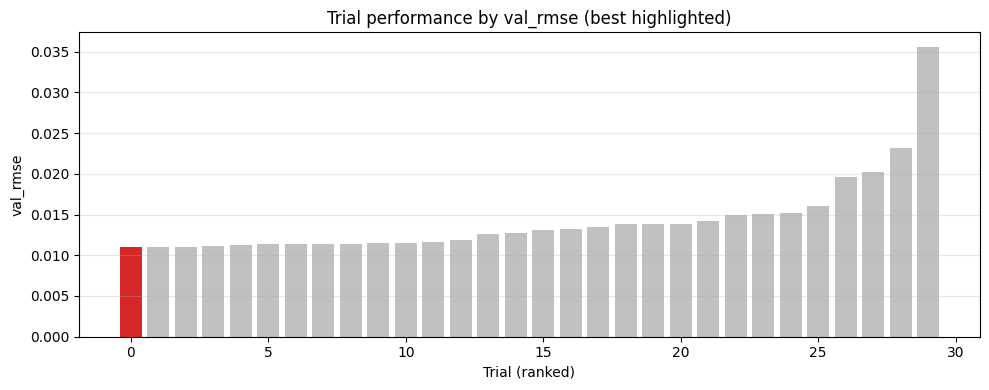

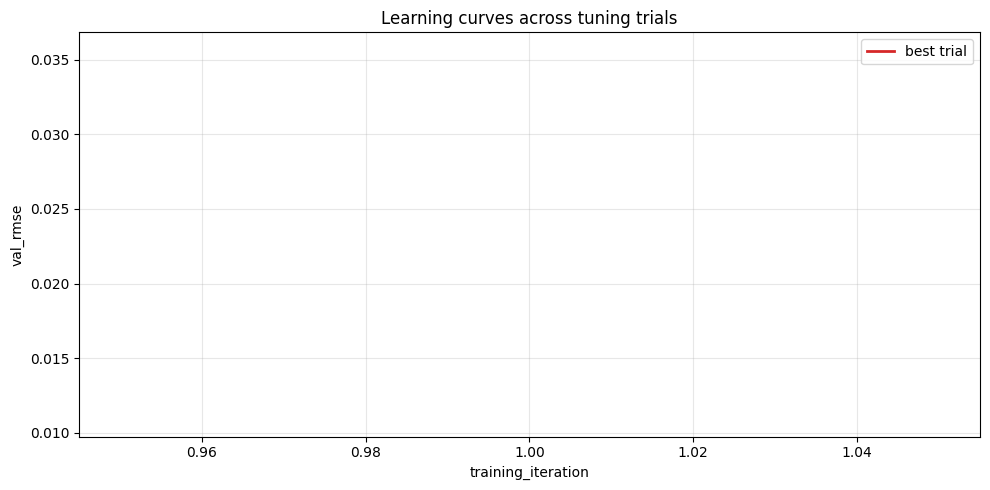

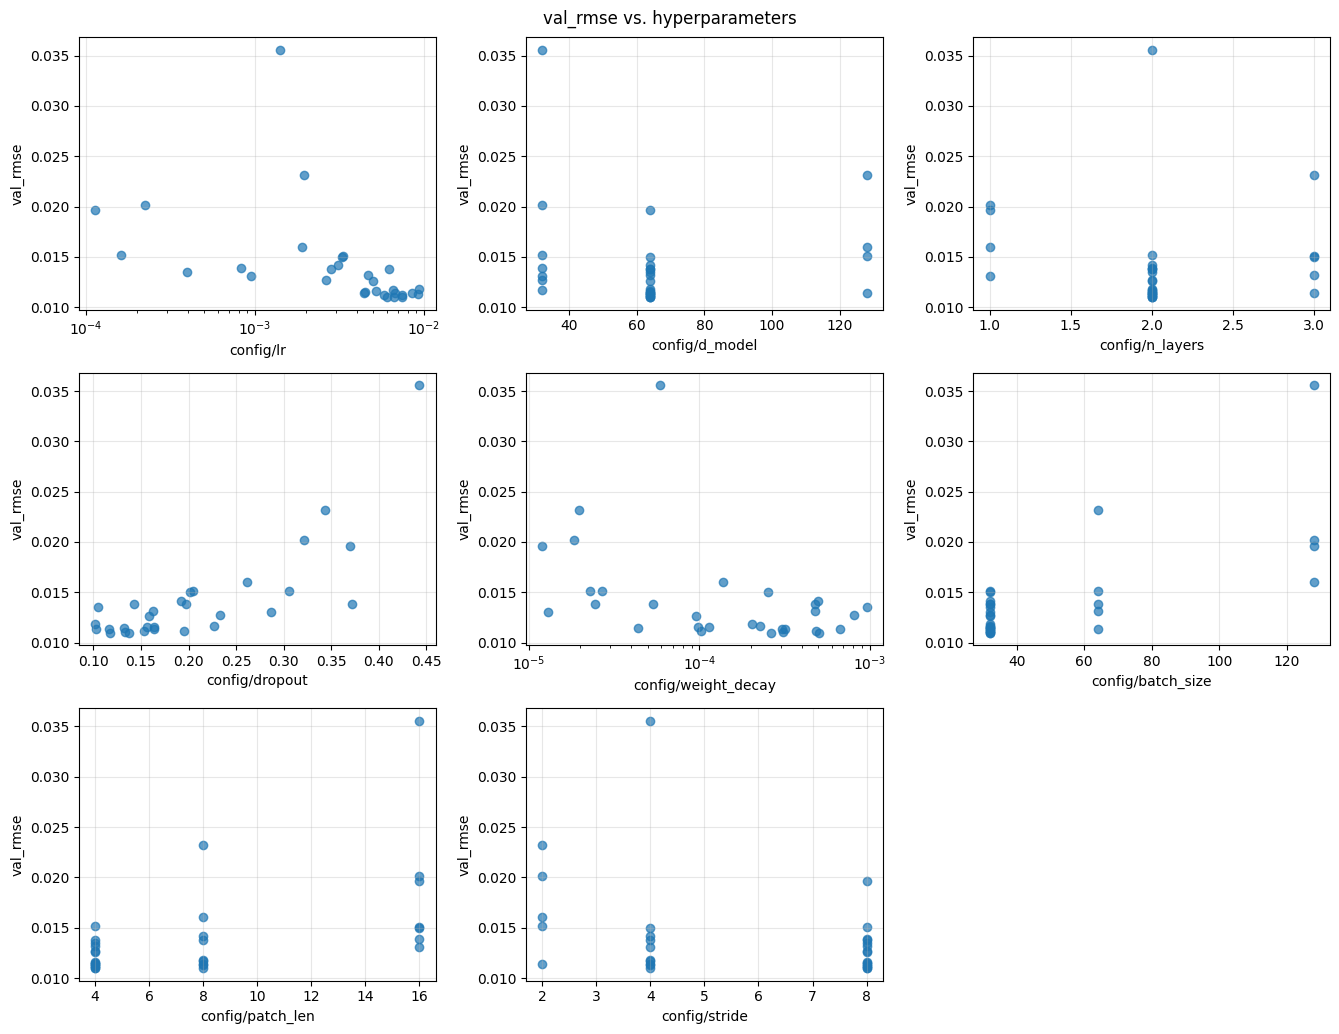

In [ ]:
# 4. Tuning summary plots
results_df = results.get_dataframe()
# results_df.sort_values('val_rmse').head(10)
results_df.sort_values(ascending=False, by='val_rmse').head(10)

plotting.plot_trial_performance(results_df, metric='val_rmse', mode='min')
plt.show()

curves = [r.metrics_dataframe for r in results]
final_vals = [c['val_rmse'].iloc[-1] if 'val_rmse' in c else np.inf for c in curves]
best_index = int(np.argmin(final_vals))
plotting.plot_learning_curves(curves, metric='val_rmse', best_index=best_index)
plt.show()

params = ['config/lr', 'config/d_model', 'config/n_layers', 'config/dropout',
          'config/weight_decay', 'config/batch_size', 'config/patch_len', 'config/stride']
plotting.plot_hyperparameter_effects(results_df, params, metric='val_rmse')
plt.show()


In [ ]:
def evaluate_patchtst(config, X_dev, y_dev, X_test, y_test,
                      max_epochs=50, scaler_factory=StandardScaler, device=None):
    """Train PatchTST on all dev data, evaluate on test set."""
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Scale per feature, pooled across timesteps -- the same convention as
    # train_model_on_fold and trainer._scale_features. Fitting on the flattened
    # window instead gives one scaler per (timestep, feature) cell, so the final
    # model would be trained under preprocessing the tuning never evaluated.
    scaler = scaler_factory() if scaler_factory else StandardScaler()
    num_features = X_dev.shape[-1]
    X_dev_scaled = scaler.fit_transform(
        X_dev.reshape(-1, num_features)
    ).reshape(X_dev.shape)
    X_test_scaled = scaler.transform(
        X_test.reshape(-1, num_features)
    ).reshape(X_test.shape)

    # Tensors
    X_dev_t = torch.tensor(X_dev_scaled, dtype=torch.float32)
    y_dev_t = torch.tensor(y_dev, dtype=torch.float32)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

    train_dataset = TensorDataset(X_dev_t, y_dev_t)
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)

    # Build model
    model = PatchTSTForecaster(
        input_dim=X_dev.shape[-1],
        horizon=y_dev.shape[1],
        patch_len=config['patch_len'],
        stride=config['stride'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        dropout=config['dropout']
    ).to(device)

    # ----- REQUIRED ATTRIBUTES for artifacts.save_run -----
    model.num_features = X_dev.shape[-1]
    model.output_size = y_dev.shape[1]
    # Provide numeric placeholders (they won't be used for PatchTST)
    model.hidden_size = 0
    model.num_layers = 0
    model.dropout = 0.0

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.MSELoss()

    # Training loop
    train_loss_history = []
    model.train()
    for epoch in range(max_epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)
        epoch_loss /= len(train_loader.dataset)
        train_loss_history.append(epoch_loss)

    # Test evaluation
    model.eval()
    with torch.no_grad():
        X_test_t = X_test_t.to(device)
        preds_t = model(X_test_t)
        preds = preds_t.cpu().numpy()
        targets = y_test

    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    direction_accuracy = np.mean((np.sign(preds) == np.sign(targets)).astype(float))

    return {
        'model': model,
        'scaler': scaler,
        'test_rmse': rmse,
        'test_directional_accuracy': direction_accuracy,
        'predictions': preds,
        'targets': targets,
        'train_loss_history': train_loss_history,
    }

Test RMSE: 0.00971
Test directional accuracy: 0.445


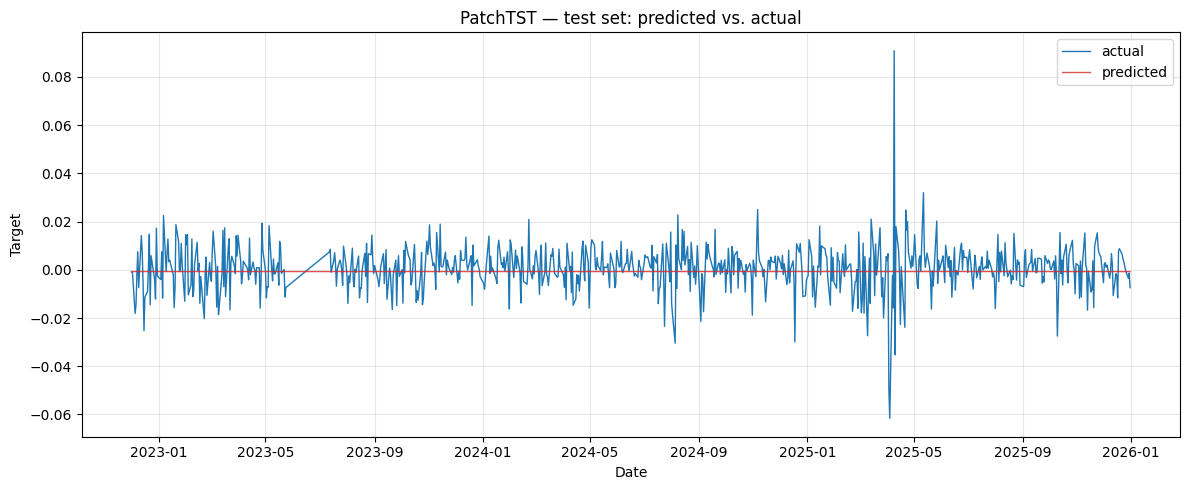

In [ ]:
# 5. Final evaluation on test set
res = evaluate_patchtst(
    best.config,
    X_dev, y_dev,
    X_test, y_test,
    max_epochs=tune_kwargs['max_epochs'],
    scaler_factory=StandardScaler
)

print(f"Test RMSE: {res['test_rmse']:.5f}")
print(f"Test directional accuracy: {res['test_directional_accuracy']:.3f}")

plotting.plot_predictions_vs_actual(
    res['targets'], res['predictions'], index=test_dates,
    title='PatchTST — test set: predicted vs. actual',
)
plt.show()

In [ ]:
# 6. Save run
run_dir = artifacts.save_run(
    'patchtst',
    res['model'],
    best.config,
    metrics={
        'test_rmse': res['test_rmse'],
        'test_directional_accuracy': res['test_directional_accuracy'],
        'best_val_rmse': best.metrics['val_rmse'],
    },
    scaler=res['scaler'],
    trials=results_df,
    learning_curves=curves,
    predictions=res['predictions'],
    targets=res['targets'],
    dates=test_dates,
    train_loss_history=res['train_loss_history'],
    extra_metadata={
        'dataset_file': BASELINE_WINDOWS_FILENAME,
        'window_shape': list(X.shape),
        'num_features': int(X.shape[-1]),
        'horizon': int(y.shape[-1]),
        'n_dev': int(len(X_dev)),
        'n_test': int(len(X_test)),
        'test_frac': TEST_FRAC,
        'n_folds': tune_kwargs['n_folds'],
        'num_samples': tune_kwargs['num_samples'],
        'max_epochs': tune_kwargs['max_epochs'],
        'scaler': 'StandardScaler',
        'smoke_test': SMOKE_TEST,
    }
)

print("Saved run ->", run_dir)
for item in sorted(os.listdir(run_dir)):
    print("  ", item)

Saved run -> /content/drive/Shareddrives/COMP 653 - Final Project/saved_models/patchtst_20260812_030702
   learning_curves.csv
   manifest.json
   model.pt
   scaler.joblib
   test_predictions.csv
   tuning_trials.csv
